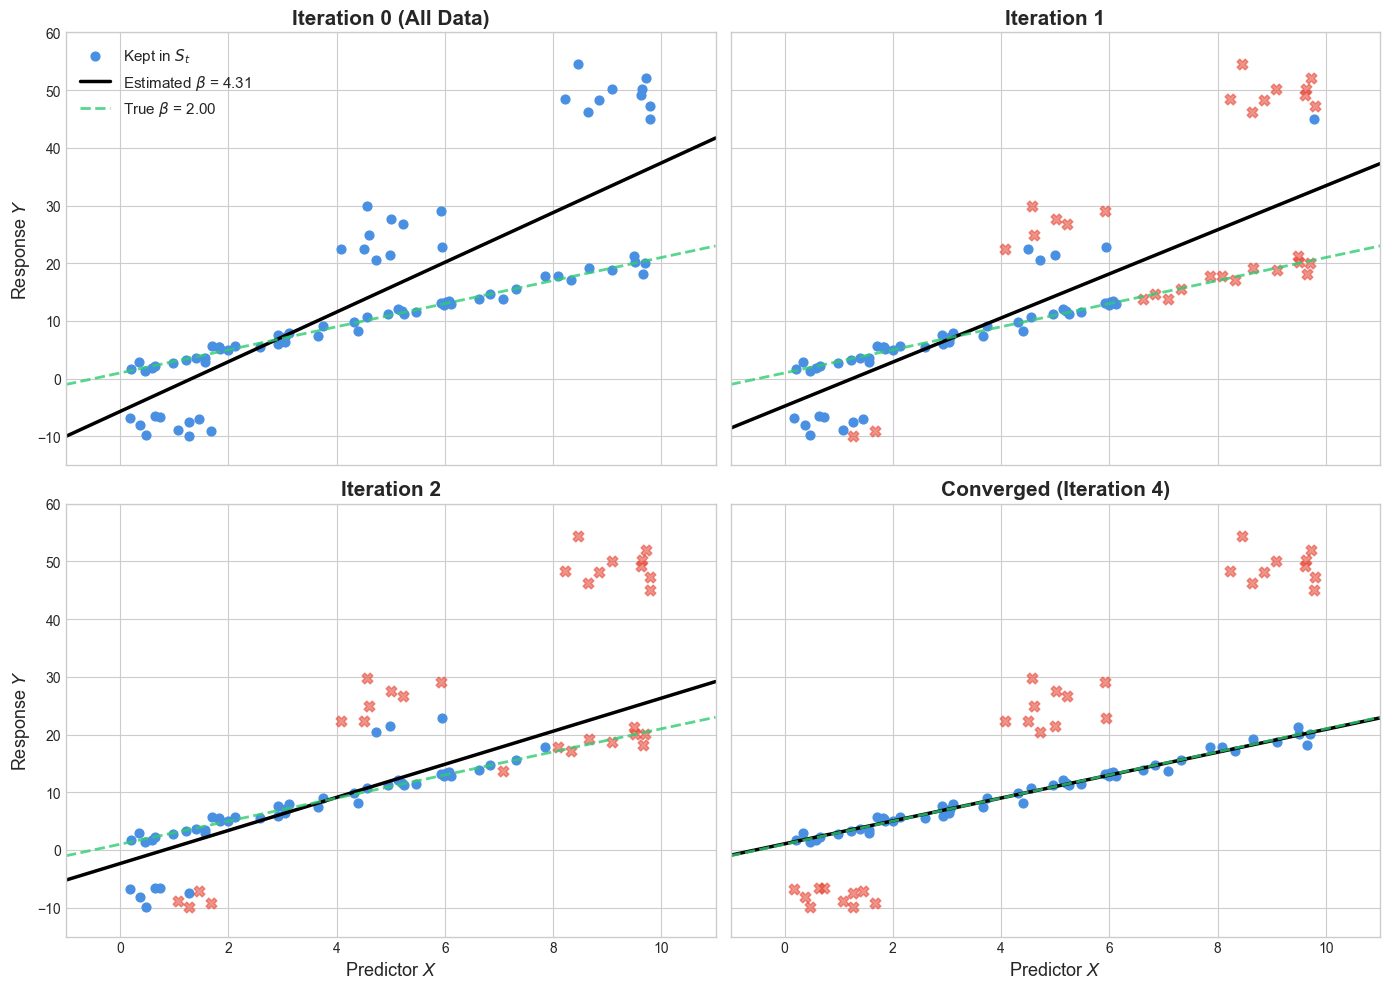

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- 1. Generate "Breadcrumb" Adversarial Data ---
np.random.seed(42)

# 50 Clean points (True relationship: y = 2x + 1)
n_clean = 50
X_clean = np.random.uniform(0, 10, n_clean)
Y_clean = 2.0 * X_clean + 1.0 + np.random.normal(0, 0.8, n_clean)

# 30 Outliers strategically placed to "bait" the regression line
# Group A: Extreme leverage (pulls the line massively up on the right)
X_outA = np.random.uniform(8, 10, 10)
Y_outA = np.random.uniform(45, 55, 10)

# Group B: Medium leverage (placed exactly where the biased line will pass)
X_outB = np.random.uniform(4, 6, 10)
Y_outB = np.random.uniform(20, 30, 10)

# Group C: Negative leverage (anchors the left side down)
X_outC = np.random.uniform(0, 2, 10)
Y_outC = np.random.uniform(-10, -5, 10)

# Combine all data
X = np.concatenate([X_clean, X_outA, X_outB, X_outC])
Y = np.concatenate([Y_clean, Y_outA, Y_outB, Y_outC])
n = len(X) # 80 total points
a = 50     # We tell the algorithm to look for 50 clean points (dropping 30)

# --- 2. The Torrent Algorithm Logic ---
history_S = []
history_models = []
S_t = np.arange(n) # Start with all points

for t in range(15): # Allow up to 15 iterations
    # Fit OLS on current clean subset
    X_curr = X[S_t].reshape(-1, 1)
    Y_curr = Y[S_t]
    model = LinearRegression().fit(X_curr, Y_curr)
    
    history_S.append(S_t.copy())
    history_models.append(model)
    
    # Calculate residuals on ALL points
    preds_all = model.predict(X.reshape(-1, 1))
    v = np.abs(Y - preds_all)
    
    # Hard Thresholding: keep indices of the 'a' smallest residuals
    S_t = np.argsort(v)[:a]
    
    # Check convergence
    if t > 0 and set(S_t) == set(history_S[-1]):
        break

# --- 3. Visualization (2x2 Grid) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()
x_plot = np.linspace(-1, 11, 100).reshape(-1, 1)

# We want to plot Iteration 0, 1, 2, and the Final Iteration
plot_indices = [0, 1, 2, len(history_models) - 1]
titles = ['Iteration 0 (All Data)', 'Iteration 1', 'Iteration 2', f'Converged (Iteration {len(history_models)-1})']

for idx, i in enumerate(plot_indices):
    ax = axes[idx]
    current_S = history_S[i]
    current_model = history_models[i]
    
    clean_mask = np.zeros(n, dtype=bool)
    clean_mask[current_S] = True
    discarded_mask = ~clean_mask
    
    # Plot points
    ax.scatter(X[clean_mask], Y[clean_mask], color='#4A90E2', s=40, label='Kept in $S_t$')
    if np.any(discarded_mask):
        ax.scatter(X[discarded_mask], Y[discarded_mask], color='#E74C3C', marker='X', s=60, alpha=0.6, label='Discarded ($\notin S_t$)')
        
    # Plot lines
    ax.plot(x_plot, current_model.predict(x_plot), color='black', linewidth=2.5, 
            label=f'Estimated $\\beta$ = {current_model.coef_[0]:.2f}')
    ax.plot(x_plot, 2.0 * x_plot + 1.0, color='#2ECC71', linestyle='--', linewidth=2, alpha=0.8, label='True $\\beta$ = 2.00')

    ax.set_title(titles[idx], fontsize=15, fontweight='bold')
    if idx >= 2: ax.set_xlabel('Predictor $X$', fontsize=13)
    if idx % 2 == 0: ax.set_ylabel('Response $Y$', fontsize=13)
    
    ax.set_xlim(-1, 11)
    ax.set_ylim(-15, 60)
    if idx == 0:
        ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('torrent_convergence.pdf', format='pdf', bbox_inches='tight')
plt.show()